# T5 Quick Run

Simple train/inference/eval run using the stock `train_best.py` (it includes train + inference) + `eval.py` scripts in `run_tapex`.


In [ ]:
!git clone https://github.com/lupantech/PromptPG.git
%cd PromptPG

In [ ]:
!pip install transformers torch pandas tqdm

In [ ]:
# Move into run_tapex
%cd run_t5


In [ ]:
# Training (train_best.py) and Evalution in one go
!python train_best.py \
    --data_root ./data/tabmwp \
    --output ../saved_models/t5_best \
    --result_root ../results/t5_best \
    --model small \
    --label exp7 \
    --epochs 10 \
    --batch_size 16 \
    --eval_batch_size 16 \
    --gpu 0 \
    --augment_ratio 0.3 \
    --use_table_tuning \
    --use_chain_of_thought \
    --use_structured_input \
    --use_curriculum \
    --save_predictions \
    --eval_split test
    --train_num 2000


In [ ]:
# Eval
!python eval.py --result_file ../results/t5_best/exp7_t5_small.json


Error counts:
  large_calculation: 2531
  small_calculation: 1944
  non_numeric: 845
  text_mismatch: 958
  off_by_factor_10: 56
  wrong_output_boolean: 227
  wrong_output_text: 1


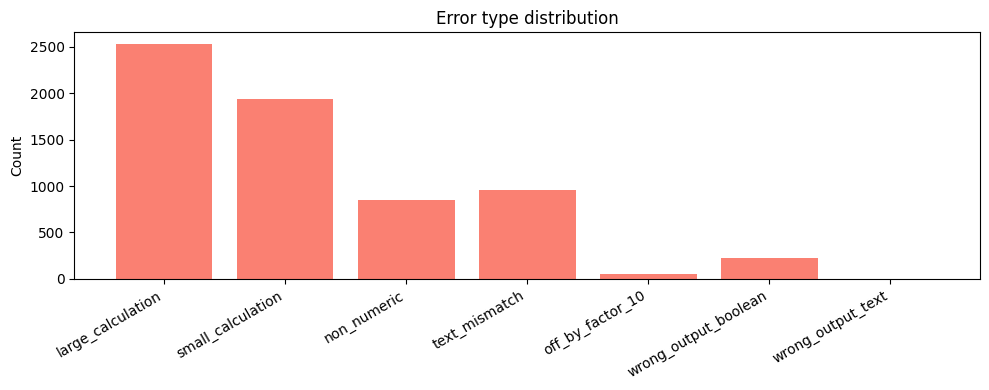

In [14]:
err_counter = get_error_distribution()
print("Error counts:")
for k,v in err_counter.items():
    print(f"  {k}: {v}")

# Plot distribution
labels = list(err_counter.keys())
values = [err_counter[k] for k in labels]
plt.figure(figsize=(10,4))
plt.bar(labels, values, color="salmon")
plt.xticks(rotation=30, ha='right')
plt.ylabel("Count")
plt.title("Error type distribution")
plt.tight_layout()
plt.show()



In [17]:
# Show a few errors by type
sampled = defaultdict(list)
for pid, prob in problems.items():
    r = results[pid]
    if r.get("true_false", False):
        continue
    etype = categorize_error(str(r.get("answer_norm", r.get("answer", ""))), str(r.get("prediction_norm", r.get("prediction", ""))))
    if etype and len(sampled[etype]) < 3:
        sampled[etype].append((pid, prob.get("question", ""), r.get("answer"), r.get("output"), r.get("prediction")))

for etype, rows in sampled.items():
    print(f"\nError type: {etype}")
    for pid, q, ans, out, pred in rows:
        print(f"- pid {pid}\n  Q: {q}\n  answer: {ans}\n  output: {out}\n  prediction: {pred}\n")




Error type: large_calculation
- pid 8
  Q: Hannah baked cookies each day for a bake sale. How many more cookies did Hannah bake on Saturday than on Sunday?
  answer: 18
  output: 263
  prediction: 263

- pid 30
  Q: Some friends played a trivia game and recorded their scores. How many more points did Hannah score than Dustin?
  answer: 650
  output: Find the numbers in the Trivia game. Hannah scored 770 more points than Dustin. Answer: 120
  prediction: 120

- pid 31
  Q: How much money does Sidney need to buy a piece of mint chocolate and 7 peanut butter cups?
  answer: 1.47
  output: Add the price of a piece of mint chocolate and the price of 7 peanut butter cups: $0.19  7141414141414141414141414141414141414141414147
  prediction: 7141414141414141414141414141414141414141414147


Error type: small_calculation
- pid 22
  Q: The employees at Tessa's Construction monitored the number of cracked window panes in each shipment they received. How many shipments had at least 40 cracked windo